# Fase 3 (revisión) — Incertidumbre y volatilidad: cuatro preguntas

Este cuaderno responde, paso a paso, a las cuatro preguntas que vertebran el trabajo,
usando los paneles mensuales construidos en el cuaderno
`cleaning_and_preparation/03_unified_panels_2014_2025.ipynb`.

1. ¿Se mueven juntas la incertidumbre y la volatilidad? → **correlación** (Pearson y Spearman).
2. ¿Es más fuerte la relación cuando la incertidumbre es alta? → **quintiles**.
3. ¿La incertidumbre anticipa la volatilidad? → **causalidad de Granger**.
4. ¿Cómo es la dinámica de la volatilidad? → **modelo GARCH(1,1)**.

Al final se guardan las figuras (`reports/figures/`) y un resumen de resultados
(`reports/resultados.json`) que alimenta la redacción del TFG.

In [1]:
import os, json, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, pearsonr, spearmanr
from statsmodels.tsa.stattools import grangercausalitytests
from arch import arch_model
warnings.filterwarnings("ignore")
ROOT = "/Users/luisgomez/Desktop/kraken/tfg-uncertainty"
PROC = f"{ROOT}/data/processed"; REP = f"{ROOT}/reports/figures"; os.makedirs(REP, exist_ok=True)
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 150, "font.size": 9,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": .25, "figure.autolayout": True})

usa   = pd.read_csv(f"{PROC}/panel_usa_mensual.csv",   index_col=0, parse_dates=True)
china = pd.read_csv(f"{PROC}/panel_china_mensual.csv", index_col=0, parse_dates=True)
dr    = pd.read_csv(f"{PROC}/rendimientos_diarios.csv", index_col=0, parse_dates=True)
mret  = pd.read_csv(f"{PROC}/rendimientos_mensuales.csv", index_col=0, parse_dates=True)
RES = {"periodo": {"inicio": str(usa.index.min().date()), "fin": str(usa.index.max().date()), "n_meses": len(usa)}}
print(RES)

{'periodo': {'inicio': '2014-01-01', 'fin': '2025-07-01', 'n_meses': 139}}


## 0. Primera mirada: estadística descriptiva de los rendimientos mensuales

In [2]:
desc = {}
for a in ["SP500", "CSI300", "Gold", "BTC"]:
    s = mret[a].dropna(); s = s[s.index.isin(usa.index)]
    desc[a] = dict(n=int(s.size), media=round(float(s.mean()), 3), sd=round(float(s.std(ddof=1)), 3),
                   min=round(float(s.min()), 3), max=round(float(s.max()), 3),
                   asimetria=round(float(skew(s)), 3), curtosis=round(float(kurtosis(s, fisher=False)), 3))
RES["descriptiva_rend_mensual"] = desc
RES["epu_desc"] = {"EPU_USA": dict(media=round(float(usa.EPU.mean()), 3),  sd=round(float(usa.EPU.std()), 3)),
                   "CNEPU":   dict(media=round(float(china.CNEPU.mean()), 3), sd=round(float(china.CNEPU.std()), 3))}
pd.DataFrame(desc).T

,n,media,sd,min,max,asimetria,curtosis
SP500,138.0,0.009,0.043,-0.134,0.119,-0.560,3.760
CSI300,138.0,0.005,0.061,-0.236,0.230,0.178,5.699
Gold,138.0,0.007,0.039,-0.081,0.100,0.155,2.475
BTC,138.0,0.035,0.202,-0.492,0.533,-0.085,3.060


## 1, 2 y 3. Correlación, quintiles y causalidad de Granger

Para cada activo se calcula de una vez: la correlación de Pearson y de Spearman entre la
incertidumbre y la volatilidad, el cociente de volatilidad media entre el quintil de mayor
y el de menor incertidumbre (Q5/Q1), y el contraste de Granger (estadístico F y p-valor del
primer retardo).

In [3]:
def analyse(panel, epucol, assets):
    out = {}
    for a in assets:
        x, y = panel[epucol], panel[f"vol_{a}"]
        q = pd.qcut(x, 5, labels=False, duplicates="drop"); m = y.groupby(q).mean()
        gr = grangercausalitytests(pd.concat([y, x], axis=1).dropna().values, maxlag=3, verbose=False)
        out[a] = dict(pearson=round(float(pearsonr(x, y)[0]), 3), spearman=round(float(spearmanr(x, y)[0]), 3),
                      q5q1=round(float(m.iloc[-1] / m.iloc[0]), 3),
                      granger_F=round(float(gr[1][0]["ssr_ftest"][0]), 3),
                      granger_p=round(float(gr[1][0]["ssr_ftest"][1]), 3))
    return out
RES["USA"]   = analyse(usa,   "EPU",   ["SP500", "Gold", "BTC"])
RES["China"] = analyse(china, "CNEPU", ["CSI300", "Gold", "BTC"])

def granger_lags(panel, epucol, assets, maxlag=3):
    out = {}
    for a in assets:
        gr = grangercausalitytests(pd.concat([panel[f"vol_{a}"], panel[epucol]], axis=1).dropna().values, maxlag=maxlag, verbose=False)
        out[a] = {str(L): {"F": round(float(gr[L][0]["ssr_ftest"][0]), 3), "p": round(float(gr[L][0]["ssr_ftest"][1]), 3)} for L in range(1, maxlag + 1)}
    return out
RES["granger_lags_USA"]   = granger_lags(usa,   "EPU",   ["SP500", "Gold", "BTC"])
RES["granger_lags_China"] = granger_lags(china, "CNEPU", ["CSI300", "Gold", "BTC"])
print("Estados Unidos:"); display(pd.DataFrame(RES["USA"]).T)
print("China:");          display(pd.DataFrame(RES["China"]).T)

Estados Unidos:


,pearson,spearman,q5q1,granger_F,granger_p
SP500,0.453,0.381,2.077,0.101,0.751
Gold,0.510,0.333,1.443,7.446,0.007
BTC,-0.050,0.001,1.124,0.939,0.334


China:


,pearson,spearman,q5q1,granger_F,granger_p
CSI300,-0.197,-0.111,0.760,1.840,0.177
Gold,0.237,0.103,1.188,0.059,0.808
BTC,-0.104,0.050,0.762,1.439,0.232


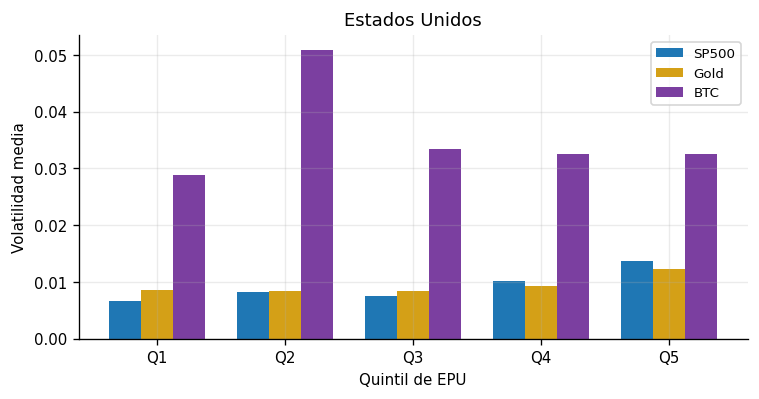

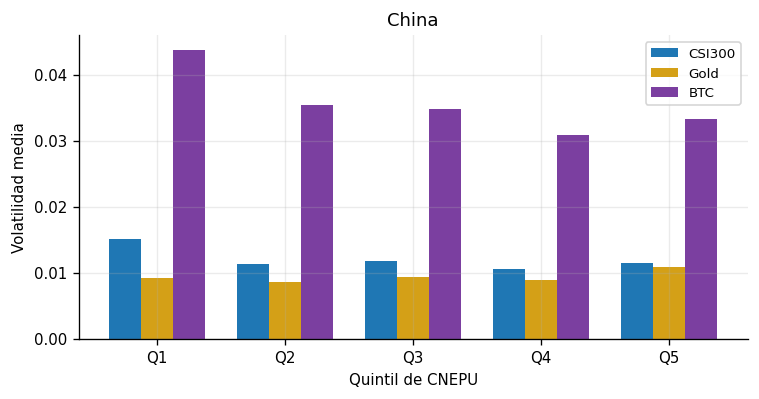

In [4]:
def quintile_fig(panel, epucol, assets, tag, title):
    fig, ax = plt.subplots(figsize=(6.4, 3.4))
    q = pd.qcut(panel[epucol], 5, labels=[f"Q{i}" for i in range(1, 6)]); w = .25
    for i, (a, c) in enumerate(zip(assets, ["#1f77b4", "#d4a017", "#7b3fa0"])):
        m = panel[f"vol_{a}"].groupby(q).mean()
        ax.bar(np.arange(5) + (i - 1) * w, m.values, w, label=a, color=c)
    ax.set_xticks(range(5)); ax.set_xticklabels([f"Q{i}" for i in range(1, 6)])
    ax.set_xlabel(f"Quintil de {epucol}"); ax.set_ylabel("Volatilidad media"); ax.legend(fontsize=8); ax.set_title(title)
    fig.savefig(f"{REP}/quintiles_{tag}.png"); return fig
quintile_fig(usa, "EPU", ["SP500", "Gold", "BTC"], "USA", "Estados Unidos")
quintile_fig(china, "CNEPU", ["CSI300", "Gold", "BTC"], "China", "China");

## 4. Modelo GARCH(1,1) de volatilidad condicional

Se estima un GARCH(1,1) con distribución t de Student sobre los rendimientos diarios de
cada activo. Interesan la persistencia (alpha + beta) y, sobre todo, si la volatilidad
condicional estimada se mueve a la vez que la incertidumbre.

In [5]:
garch, cond = {}, {}
for a in ["SP500", "CSI300", "Gold", "BTC"]:
    r = dr[a].dropna() * 100.0
    fit = arch_model(r, mean="Constant", vol="GARCH", p=1, q=1, dist="t").fit(disp="off")
    pa = fit.params
    garch[a] = dict(mu=round(float(pa["mu"]), 3), omega=round(float(pa["omega"]), 3),
                    alpha=round(float(pa["alpha[1]"]), 3), beta=round(float(pa["beta[1]"]), 3),
                    persist=round(float(pa["alpha[1]"] + pa["beta[1]"]), 3), nu=round(float(pa["nu"]), 3))
    cv = pd.Series(np.asarray(fit.conditional_volatility), index=r.index)
    cm = cv.groupby(cv.index.values.astype("datetime64[M]")).mean(); cm.index = pd.to_datetime(cm.index)
    cond[a] = cm
RES["GARCH"] = garch
def corr_cond(panel, epucol, a):
    s = cond[a].reindex(panel.index).dropna(); x = panel[epucol].reindex(s.index)
    return round(float(pearsonr(x, s)[0]), 3)
RES["cond_vs_epu_USA"]   = {a: corr_cond(usa,   "EPU",   a) for a in ["SP500", "Gold", "BTC"]}
RES["cond_vs_epu_China"] = {a: corr_cond(china, "CNEPU", a) for a in ["CSI300", "Gold", "BTC"]}
pd.DataFrame(RES["GARCH"]).T

,mu,omega,alpha,beta,persist,nu
SP500,0.093,0.023,0.182,0.813,0.996,5.435
CSI300,0.032,0.022,0.076,0.914,0.990,4.910
Gold,0.034,0.017,0.032,0.953,0.986,4.306
BTC,0.119,0.377,0.149,0.851,1.000,3.050


## 5. Series temporales, modelo GARCH frente a la incertidumbre y cambio de régimen

Correlacion EPU-vol S&P500  antes de 2020: 0.103 | desde 2020: 0.407


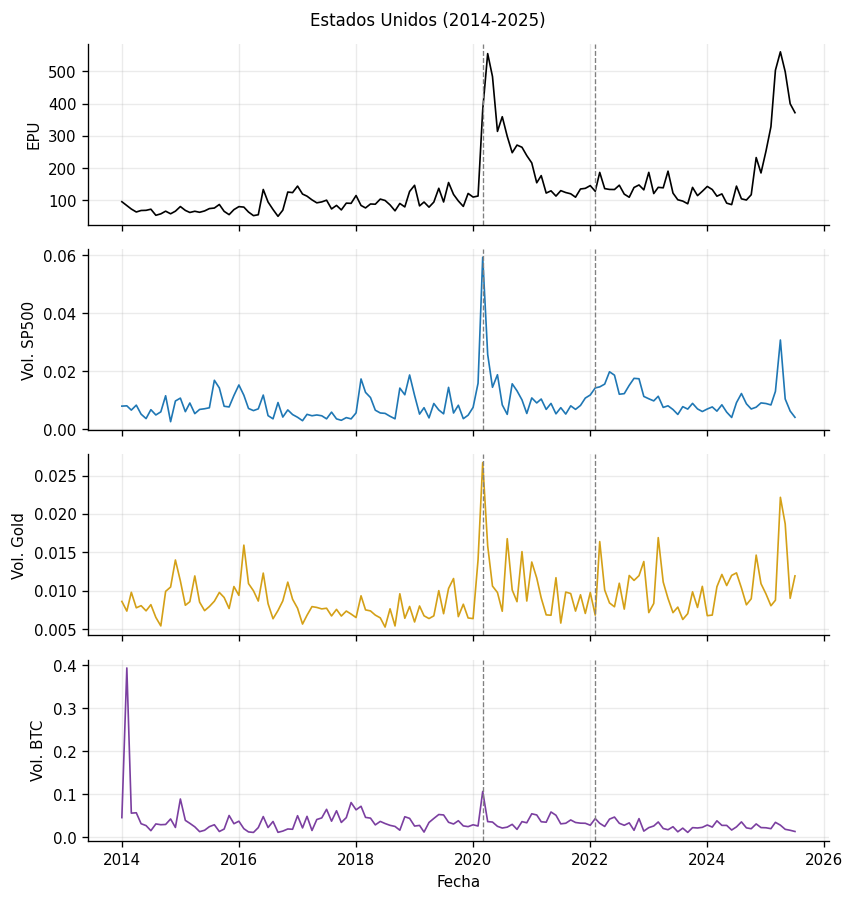

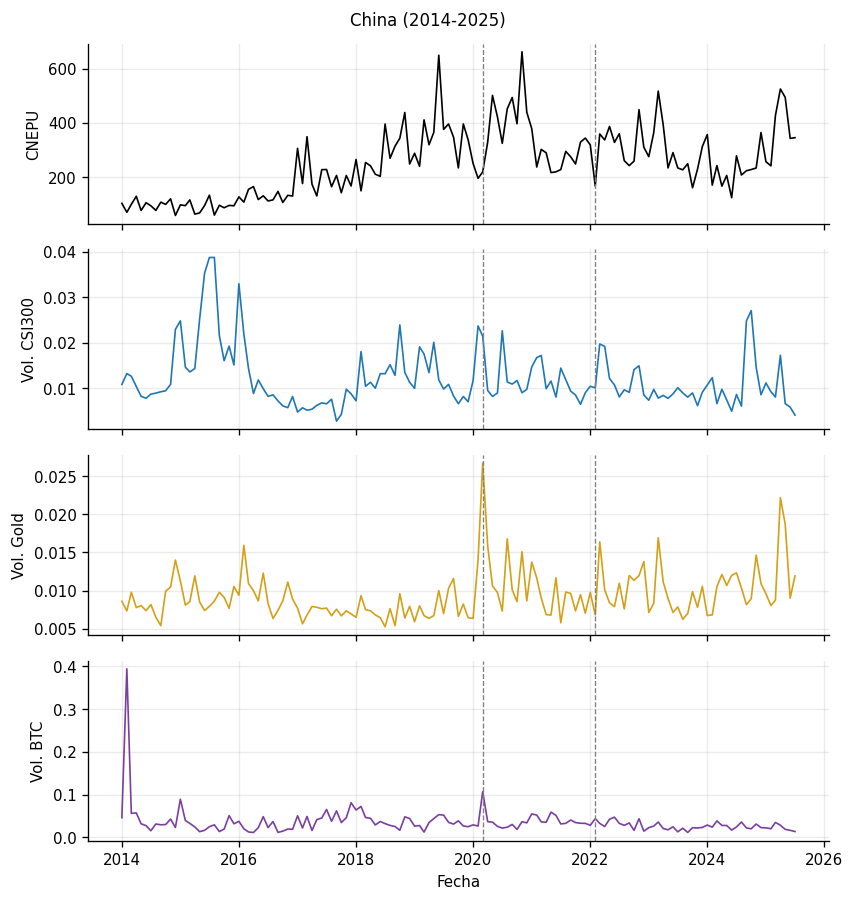

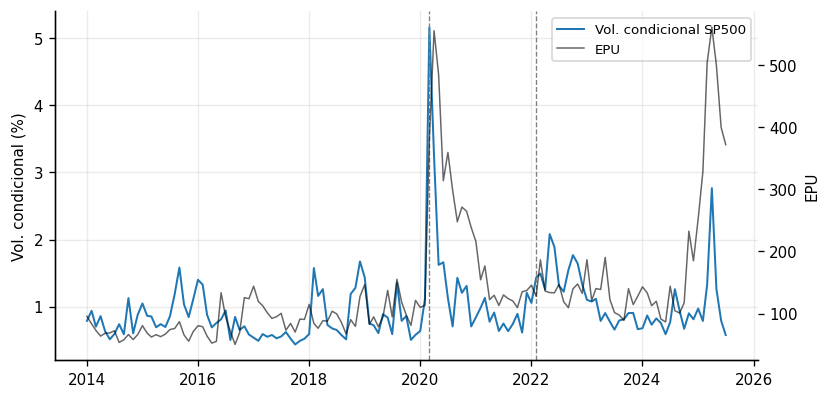

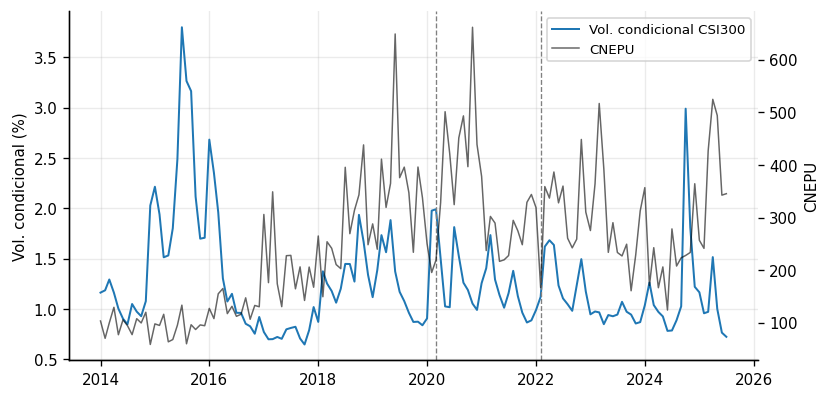

In [6]:
CR = {"2020-03-01": "COVID", "2022-02-01": "Ucrania"}
def serie_fig(panel, epucol, assets, tag, title):
    fig, axes = plt.subplots(4, 1, figsize=(7.2, 7.6), sharex=True)
    axes[0].plot(panel.index, panel[epucol], color="black", lw=1); axes[0].set_ylabel(epucol)
    for ax, a, c in zip(axes[1:], assets, ["#1f77b4", "#d4a017", "#7b3fa0"]):
        ax.plot(panel.index, panel[f"vol_{a}"], color=c, lw=1); ax.set_ylabel(f"Vol. {a}")
    for ax in axes:
        for d in CR: ax.axvline(pd.Timestamp(d), color="grey", ls="--", lw=.8)
    axes[-1].set_xlabel("Fecha"); fig.suptitle(title, fontsize=10)
    fig.savefig(f"{REP}/serie_{tag}.png"); return fig
y0, y1 = usa.index.min().year, usa.index.max().year
serie_fig(usa, "EPU", ["SP500", "Gold", "BTC"], "USA", f"Estados Unidos ({y0}-{y1})")
serie_fig(china, "CNEPU", ["CSI300", "Gold", "BTC"], "China", f"China ({y0}-{y1})")

def garch_fig(panel, epucol, idx, tag):
    fig, ax = plt.subplots(figsize=(7.0, 3.4))
    ax.plot(panel.index, cond[idx].reindex(panel.index), color="#1f77b4", lw=1.2, label=f"Vol. condicional {idx}")
    ax2 = ax.twinx(); ax2.plot(panel.index, panel[epucol], color="black", lw=.9, alpha=.6, label=epucol); ax2.grid(False)
    ax.set_ylabel("Vol. condicional (%)"); ax2.set_ylabel(epucol)
    for d in CR: ax.axvline(pd.Timestamp(d), color="grey", ls="--", lw=.8)
    h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, fontsize=8); fig.savefig(f"{REP}/garch_{tag}.png"); return fig
garch_fig(usa, "EPU", "SP500", "USA"); garch_fig(china, "CNEPU", "CSI300", "China")

def split(panel, epucol, a, cut="2020-01-01"):
    pre, post = panel[panel.index < cut], panel[panel.index >= cut]
    return round(float(pearsonr(pre[epucol], pre[f"vol_{a}"])[0]), 3), round(float(pearsonr(post[epucol], post[f"vol_{a}"])[0]), 3)
RES["ruptura_SP500"] = dict(zip(["pre2020", "post2020"], split(usa, "EPU", "SP500")))
print("Correlacion EPU-vol S&P500  antes de 2020:", RES["ruptura_SP500"]["pre2020"],
      "| desde 2020:", RES["ruptura_SP500"]["post2020"])

## 6. Guardado de resultados para la redacción

In [7]:
os.makedirs(f"{ROOT}/reports", exist_ok=True)
json.dump(RES, open(f"{ROOT}/reports/resultados.json", "w"), ensure_ascii=False, indent=1)
print("Guardado en reports/resultados.json y figuras en reports/figures/")
RES

Guardado en reports/resultados.json y figuras en reports/figures/


{'periodo': {'inicio': '2014-01-01', 'fin': '2025-07-01', 'n_meses': 139},
 'descriptiva_rend_mensual': {'SP500': {'n': 138,
   'media': 0.009,
   'sd': 0.043,
   'min': -0.134,
   'max': 0.119,
   'asimetria': -0.56,
   'curtosis': 3.76},
  'CSI300': {'n': 138,
   'media': 0.005,
   'sd': 0.061,
   'min': -0.236,
   'max': 0.23,
   'asimetria': 0.178,
   'curtosis': 5.699},
  'Gold': {'n': 138,
   'media': 0.007,
   'sd': 0.039,
   'min': -0.081,
   'max': 0.1,
   'asimetria': 0.155,
   'curtosis': 2.475},
  'BTC': {'n': 138,
   'media': 0.035,
   'sd': 0.202,
   'min': -0.492,
   'max': 0.533,
   'asimetria': -0.085,
   'curtosis': 3.06}},
 'epu_desc': {'EPU_USA': {'media': 138.648, 'sd': 101.028},
  'CNEPU': {'media': 249.84, 'sd': 125.082}},
 'USA': {'SP500': {'pearson': 0.453,
   'spearman': 0.381,
   'q5q1': 2.077,
   'granger_F': 0.101,
   'granger_p': 0.751},
  'Gold': {'pearson': 0.51,
   'spearman': 0.333,
   'q5q1': 1.443,
   'granger_F': 7.446,
   'granger_p': 0.007},
  'BT